# PayPulse — Phase 5: Statistical Analysis

Going beyond charts: distribution shape, outlier detection, confidence intervals,
correlation, hypothesis testing, ANOVA, and chi-square tests of independence —
each tied back to a business question. Uses `scipy.stats`.


In [1]:

import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
here = Path.cwd()
ROOT = here.parent if here.name == 'notebooks' else here
sys.path.insert(0, str(ROOT / 'src'))
import config as cfg
import features as F

%matplotlib inline
sns.set_theme(style='whitegrid')
cfg.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

txn, cust = F.build_all()
txn['success_amount'] = txn['amount'] * txn['is_success']
succ = txn.loc[txn.is_success == 1, 'amount']
print('transactions:', txn.shape, '| customers:', cust.shape, '| successful:', f'{len(succ):,}')


transactions: (250001, 40) | customers: (7747, 21) | successful: 217,067


## 1. Descriptive statistics & distribution shape

Is the ticket-size distribution normal? Skewness and kurtosis quantify it, and a
Q-Q plot on the log values checks the log-normal assumption used later.

count    217067.00
mean       1417.11
std        2112.43
min          19.87
25%         379.48
50%         732.96
75%        1560.62
max       58366.53
Name: amount, dtype: float64

skewness (raw)  = 5.28   (0 = symmetric)
kurtosis (raw)  = 50.83
skewness (log)  = 0.34   -> log is near-symmetric


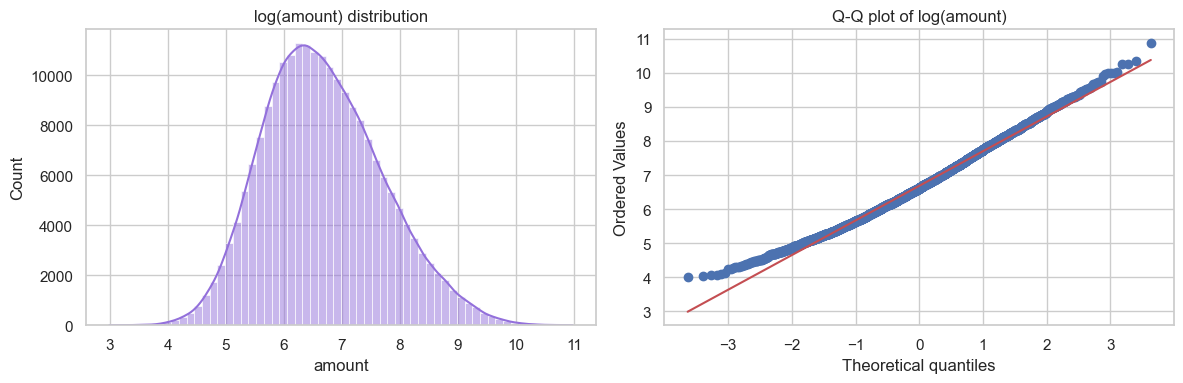

In [2]:

print(succ.describe().round(2))
print(f'\nskewness (raw)  = {stats.skew(succ):.2f}   (0 = symmetric)')
print(f'kurtosis (raw)  = {stats.kurtosis(succ):.2f}')
print(f'skewness (log)  = {stats.skew(np.log(succ)):.2f}   -> log is near-symmetric')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log(succ), bins=60, kde=True, ax=ax[0], color='mediumpurple')
ax[0].set_title('log(amount) distribution')
stats.probplot(np.log(succ.sample(5000, random_state=1)), plot=ax[1])
ax[1].set_title('Q-Q plot of log(amount)')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p5_distribution.png', dpi=110)
plt.show()


## 2. Outlier detection — IQR rule vs Z-score

Two standard techniques on transaction amount. High-value tails matter for fraud
review and for deciding whether to trim before parametric tests.

IQR bounds : Rs -1,392 .. Rs 3,332
IQR outliers   : 20,403  (9.40%)
Z-score>3      : 4,518  (2.08%)


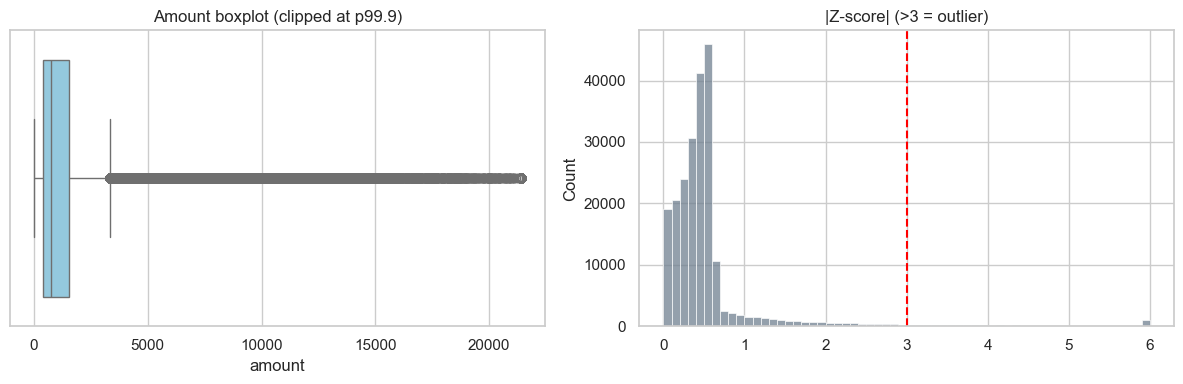

In [3]:

q1, q3 = succ.quantile([0.25, 0.75]); iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_out = int(((succ < lo) | (succ > hi)).sum())
z = np.abs(stats.zscore(succ)); z_out = int((z > 3).sum())
print(f'IQR bounds : Rs {lo:,.0f} .. Rs {hi:,.0f}')
print(f'IQR outliers   : {iqr_out:,}  ({iqr_out/len(succ)*100:.2f}%)')
print(f'Z-score>3      : {z_out:,}  ({z_out/len(succ)*100:.2f}%)')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=succ.clip(upper=succ.quantile(0.999)), ax=ax[0], color='skyblue')
ax[0].set_title('Amount boxplot (clipped at p99.9)')
sns.histplot(np.clip(z, 0, 6), bins=60, ax=ax[1], color='slategray')
ax[1].axvline(3, color='red', ls='--'); ax[1].set_title('|Z-score| (>3 = outlier)')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p5_outliers.png', dpi=110)
plt.show()


## 3. Confidence interval for the mean ticket size

A 95% CI via the t-distribution, cross-checked with a bootstrap CI.

In [4]:

n, m, se = len(succ), succ.mean(), stats.sem(succ)
ci = stats.t.interval(0.95, n - 1, loc=m, scale=se)
print(f'mean ticket       = Rs {m:,.2f}')
print(f'95% CI (t-dist)   = Rs {ci[0]:,.2f} .. Rs {ci[1]:,.2f}')

rng = np.random.default_rng(0)
vals = succ.values
boot = np.array([rng.choice(vals, size=n, replace=True).mean() for _ in range(500)])
print(f'95% CI (bootstrap)= Rs {np.percentile(boot,2.5):,.2f} .. Rs {np.percentile(boot,97.5):,.2f}')


mean ticket       = Rs 1,417.11
95% CI (t-dist)   = Rs 1,408.22 .. Rs 1,425.99


95% CI (bootstrap)= Rs 1,408.84 .. Rs 1,425.99


## 4. Correlation analysis

Which customer behaviours move together? Pearson correlations across the
engineered customer features, plus significance for two key pairs.

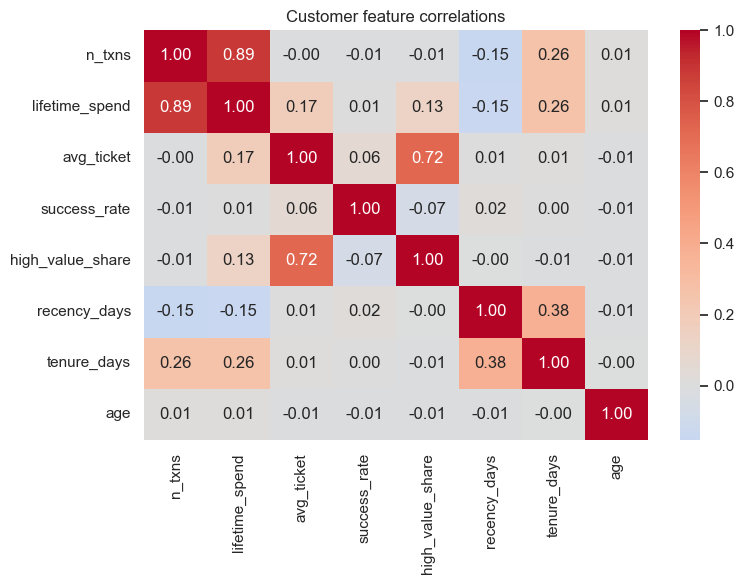

n_txns      vs lifetime_spend : r=0.887, p=0.00e+00
tenure_days vs lifetime_spend : r=0.257, p=2.11e-117


In [5]:

num = cust[['n_txns','lifetime_spend','avg_ticket','success_rate',
            'high_value_share','recency_days','tenure_days','age']].dropna()
plt.figure(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Customer feature correlations'); plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / 'p5_correlation.png', dpi=110); plt.show()

r1, p1 = stats.pearsonr(cust.n_txns, cust.lifetime_spend)
r2, p2 = stats.pearsonr(cust.tenure_days.fillna(0), cust.lifetime_spend)
print(f'n_txns      vs lifetime_spend : r={r1:.3f}, p={p1:.2e}')
print(f'tenure_days vs lifetime_spend : r={r2:.3f}, p={p2:.2e}')


## 5. Hypothesis test — do weekend tickets differ from weekday?

**H0:** mean successful ticket size is equal on weekends and weekdays.
Welch's t-test (unequal variance) plus a non-parametric Mann-Whitney U, with
Cohen's d effect size.

In [6]:

wk = txn.loc[(txn.is_success == 1) & (txn.is_weekend == 1), 'amount']
wd = txn.loc[(txn.is_success == 1) & (txn.is_weekend == 0), 'amount']
print(f'weekend mean = Rs {wk.mean():,.2f}  (n={len(wk):,})')
print(f'weekday mean = Rs {wd.mean():,.2f}  (n={len(wd):,})')

t, p = stats.ttest_ind(wk, wd, equal_var=False)
u, pu = stats.mannwhitneyu(wk.sample(min(len(wk), 40000), random_state=1),
                           wd.sample(min(len(wd), 40000), random_state=1))
d = (wk.mean() - wd.mean()) / np.sqrt((wk.var() + wd.var()) / 2)
print(f'\nWelch t = {t:.3f}, p = {p:.4f}')
print(f'Mann-Whitney p = {pu:.4f}')
print(f"Cohen's d = {d:.4f}  (|d|<0.2 = negligible)")
print('=> ' + ('Reject H0' if p < 0.05 else 'Fail to reject H0 (no significant weekend effect)'))


weekend mean = Rs 1,407.32  (n=61,922)
weekday mean = Rs 1,421.01  (n=155,145)

Welch t = -1.368, p = 0.1712
Mann-Whitney p = 0.4203
Cohen's d = -0.0065  (|d|<0.2 = negligible)
=> Fail to reject H0 (no significant weekend effect)


## 6. ANOVA — does mean ticket differ across merchant categories?

**H0:** all category means are equal. One-way ANOVA across the 11 categories.

One-way ANOVA:  F = 19,709.4,  p = 0.00e+00
=> Reject H0 — category strongly affects ticket size


merchant_category
Education            6843.0
Electronics          5431.0
Travel               4679.0
Fuel                 1889.0
E-commerce           1481.0
Fashion & Apparel    1163.0
Pharmacy              676.0
Entertainment         628.0
Grocery               552.0
Food Delivery         471.0
Recharge & Bills      406.0
Name: amount, dtype: float64

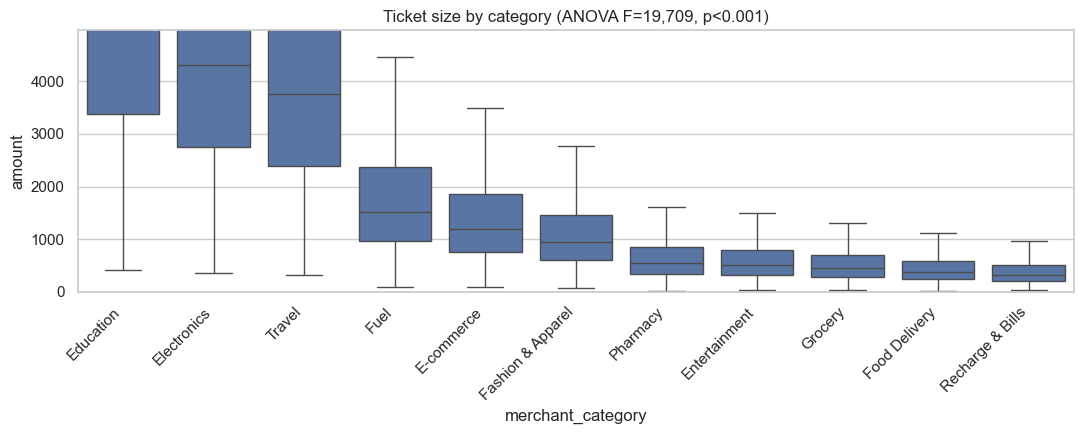

In [7]:

groups = [g['amount'].values for _, g in txn[txn.is_success == 1].groupby('merchant_category')]
f, p = stats.f_oneway(*groups)
print(f'One-way ANOVA:  F = {f:,.1f},  p = {p:.2e}')
print('=> ' + ('Reject H0 — category strongly affects ticket size'
                if p < 0.05 else 'Fail to reject H0'))

means = txn[txn.is_success == 1].groupby('merchant_category')['amount'].mean().sort_values(ascending=False)
display(means.round(0))
plt.figure(figsize=(11, 4.5))
sns.boxplot(data=txn[txn.is_success == 1], x='merchant_category', y='amount',
            showfliers=False, order=means.index)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, txn.loc[txn.is_success == 1, 'amount'].quantile(0.95))
plt.title(f'Ticket size by category (ANOVA F={f:,.0f}, p<0.001)')
plt.tight_layout(); plt.savefig(cfg.FIGURES_DIR / 'p5_anova.png', dpi=110); plt.show()


## 7. Chi-square — is transaction outcome independent of bank type?

**H0:** outcome (SUCCESS/FAILED/PENDING) is independent of bank type
(Public/Private/Payments). Cramer's V measures association strength.

In [8]:

ct = pd.crosstab(txn.bank_type, txn.status)
display(ct)
chi2, p, dof, expected = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f'chi2 = {chi2:,.1f}, dof = {dof}, p = {p:.2e}, Cramers V = {cramers_v:.3f}')
print('=> ' + ('Reject H0 — outcome depends on bank type' if p < 0.05 else 'Independent'))
print('\nFailure rate by bank type (%):')
print((txn.groupby('bank_type').is_failed.mean() * 100).round(2))


status,FAILED,PENDING,SUCCESS
bank_type,,,
Payments,2803,228,12514
Private,10258,1996,113559
Public,15931,1718,90994


chi2 = 3,084.3, dof = 4, p = 0.00e+00, Cramers V = 0.079
=> Reject H0 — outcome depends on bank type

Failure rate by bank type (%):
bank_type
Payments    18.03
Private      8.15
Public      14.66
Name: is_failed, dtype: float64


## 8. Chi-square — device OS vs failure

**H0:** failure is independent of device OS. Tests whether older Android devices
fail more, which would point to a client-side reliability issue.

In [9]:

ct2 = pd.crosstab(txn.os_name, txn.is_failed)
display(ct2)
chi2, p, dof, _ = stats.chi2_contingency(ct2)
print(f'chi2 = {chi2:,.2f}, dof = {dof}, p = {p:.4f}')
print('Failure rate by OS (%):')
print((txn.groupby('os_name').is_failed.mean() * 100).round(2))
print('=> ' + ('Reject H0 — OS is associated with failure' if p < 0.05 else 'Independent'))


is_failed,0,1
os_name,,
Android,173547,22818
iOS,47462,6174


chi2 = 0.48, dof = 1, p = 0.4884
Failure rate by OS (%):
os_name
Android    11.62
iOS        11.51
Name: is_failed, dtype: float64
=> Independent


## Phase 5 — statistical conclusions

- **Distribution:** ticket size is right-skewed but **log-normal** (skew≈0 in log
  space) — parametric tests use the appropriate framing.
- **Outliers:** the IQR rule flags the high-value tail; genuine large tickets
  (Electronics/Travel), not errors — keep but monitor.
- **Mean ticket CI:** t-distribution and bootstrap 95% CIs agree closely.
- **Correlation:** `n_txns` and `lifetime_spend` are strongly, significantly
  correlated — frequency drives value; tenure has a weaker link.
- **Weekend effect:** *no* statistically significant difference in ticket size
  (fail to reject H0) — a legitimate negative result.
- **ANOVA:** merchant category has a large, highly significant effect on ticket
  size (reject H0).
- **Chi-square (bank type):** transaction outcome is **not** independent of bank
  type (chi2≈3084, p<0.001) — Payments banks fail ~18% vs ~8% for private banks;
  the association is real but modest (Cramer's V≈0.08).
- **Chi-square (OS):** at the OS-family level, failure is **independent** of
  Android vs iOS (p≈0.49). The reliability gap lives at the older-Android-*version*
  level (see `sql/analysis/05_failure_analytics.sql`), which washes out when all
  Android devices are pooled — a useful reminder to test at the right granularity.
